##Code

100%|██████████| 426M/426M [00:05<00:00, 81.7MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/stpeteishii/pascal-voc-2007-dataset/versions/1
Searching for 'JPEGImages' in '/root/.cache/kagglehub/datasets/stpeteishii/pascal-voc-2007-dataset/versions/1'...
Found! Path: /root/.cache/kagglehub/datasets/stpeteishii/pascal-voc-2007-dataset/versions/1/VOCdevkit2007/VOC2007/JPEGImages
Searching for 'SegmentationClass' in '/root/.cache/kagglehub/datasets/stpeteishii/pascal-voc-2007-dataset/versions/1'...
Found! Path: /root/.cache/kagglehub/datasets/stpeteishii/pascal-voc-2007-dataset/versions/1/VOCdevkit2007/VOC2007/SegmentationClass
Searching for the 4st/nd/rd image with at least 3 classes...
Found suitable image: 000793.jpg
Loading image: /root/.cache/kagglehub/datasets/stpeteishii/pascal-voc-2007-dataset/versions/1/VOCdevkit2007/VOC2007/JPEGImages/000793.jpg
Loading mask: /root/.cache/kagglehub/datasets/stpeteishii/pascal-voc-2007-dataset/versions/1/VOCdevkit2007/VOC2007/SegmentationClass/000793.png
Using device: cpu
Downloading:

100%|██████████| 161M/161M [00:03<00:00, 43.0MB/s]



--- Running Evaluation on KaggleHub Image ---
Classes found in Ground Truth: ['bicycle', 'bus', 'person']


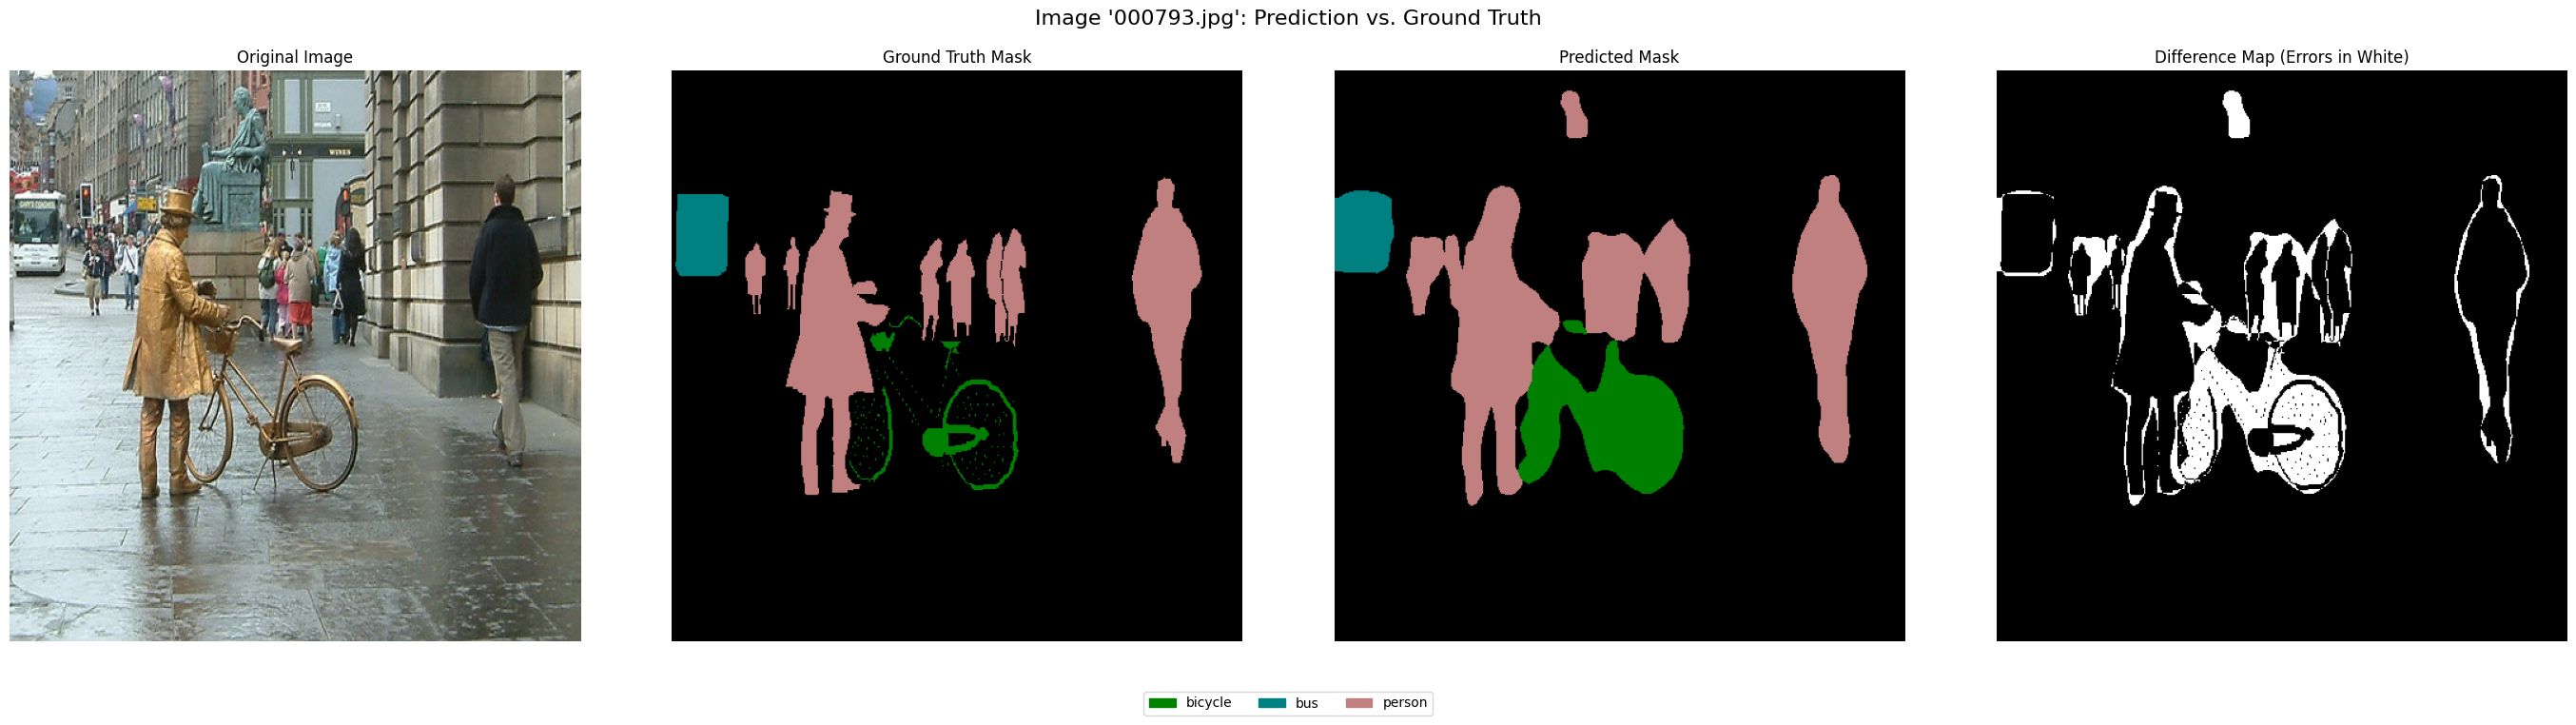


--- Generating Per-Class Visual Confusion Maps ---


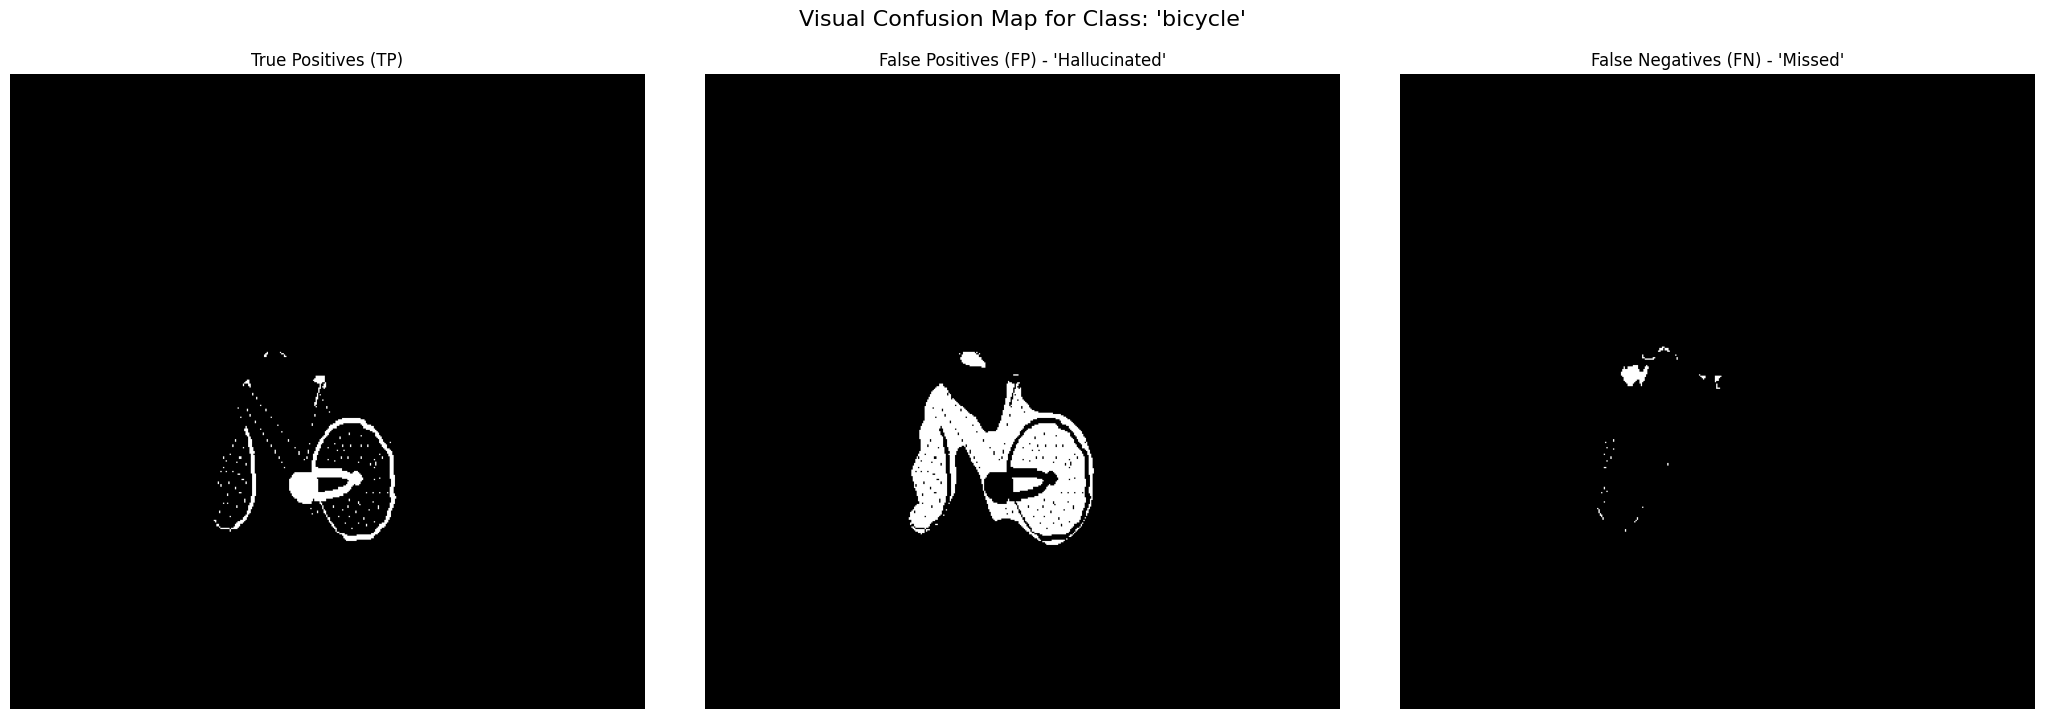

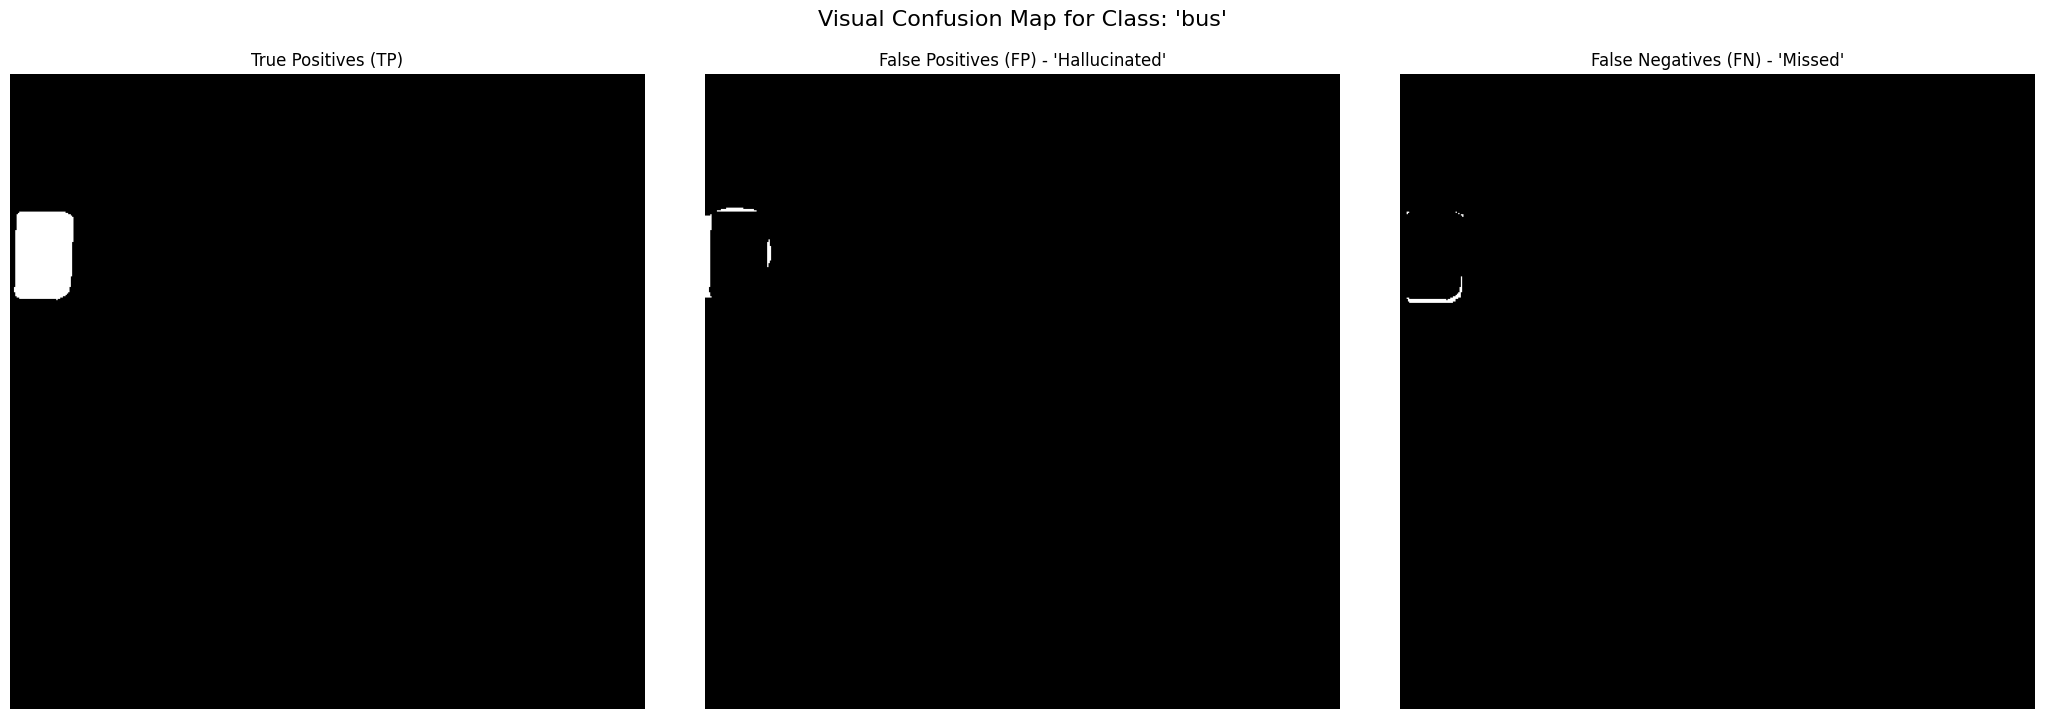

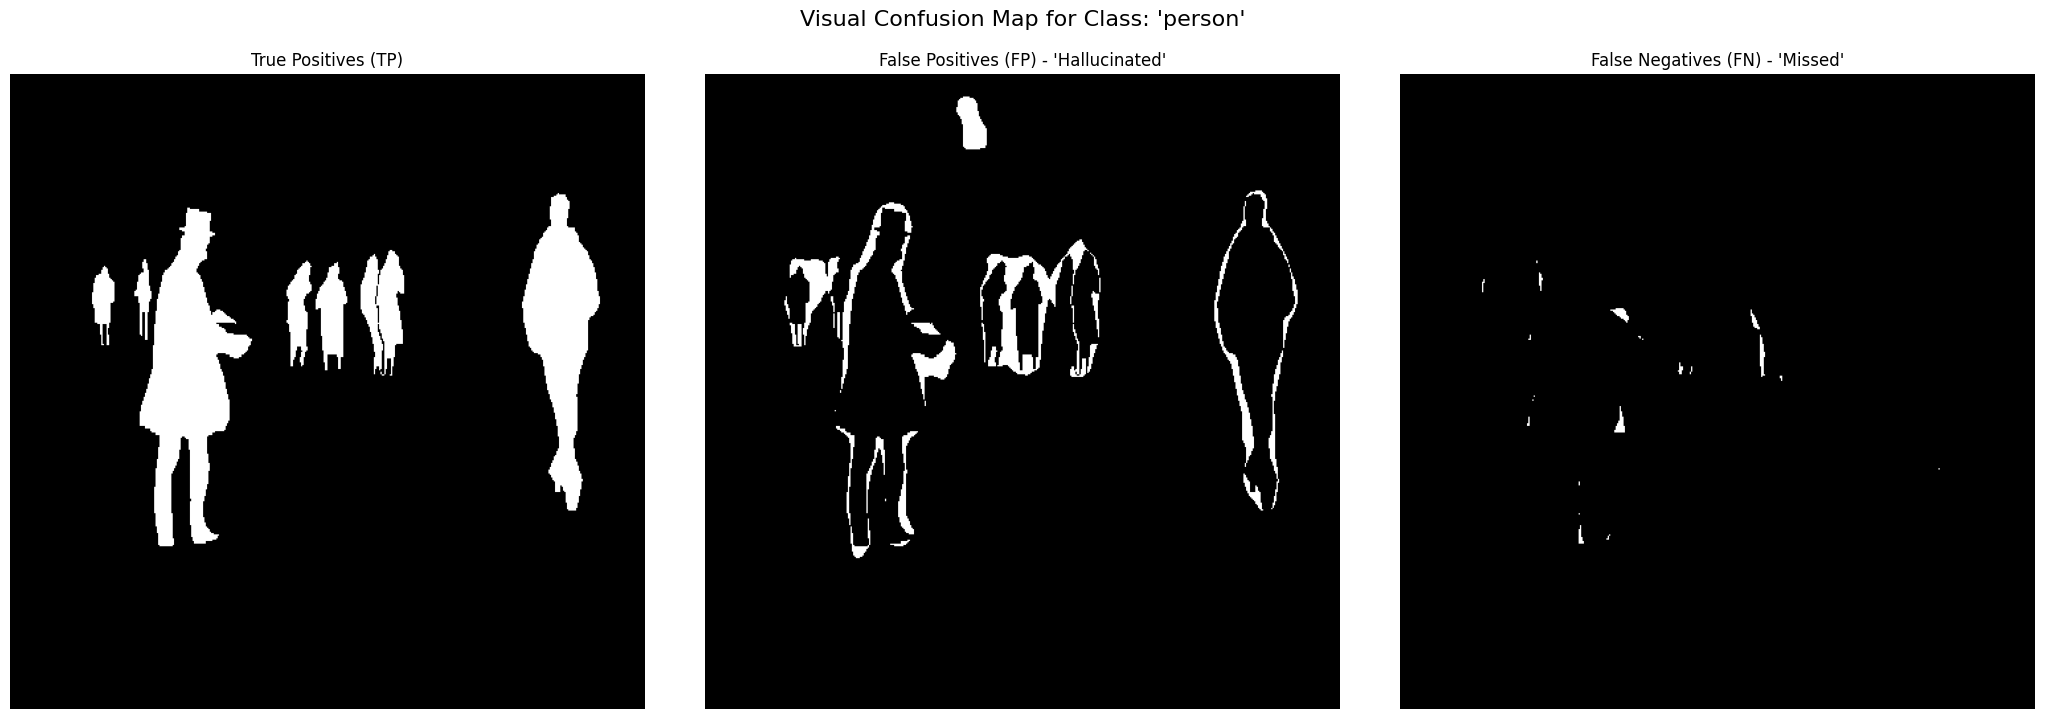


--- Final Evaluation Results ---
Class        | IoU      | Dice     | PixAcc  
----------------------------------------
bicycle      | 0.1856   | 0.3131   | 0.9607  
bus          | 0.8418   | 0.9141   | 0.9977  
person       | 0.7131   | 0.8325   | 0.9619  
----------------------------------------
Mean IoU (mIoU) across 3 classes: 0.5802

--- Per-Class Confusion Metrics (Pixel Counts) ---

Class: 'bicycle'
  True Positives (TP):        2066 (Correctly predicted pixels)
  False Positives (FP):       8752 (Predicted as 'bicycle', but wasn't)
  False Negatives (FN):        313 (Was 'bicycle', but model missed it)

Class: 'bus'
  True Positives (TP):        2788 (Correctly predicted pixels)
  False Positives (FP):        373 (Predicted as 'bus', but wasn't)
  False Negatives (FN):        151 (Was 'bus', but model missed it)

Class: 'person'
  True Positives (TP):       21808 (Correctly predicted pixels)
  False Positives (FP):       8371 (Predicted as 'person', but wasn't)
  False Negativ

In [1]:
# --- 1. Install and Import KaggleHub ---
!pip install kagglehub -q
import kagglehub
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import models, transforms, datasets
from PIL import Image, ImageDraw
import requests
from io import BytesIO

# --- 2. Download Dataset via KaggleHub ---
print("Downloading PASCAL VOC 2007 dataset via KaggleHub...")
try:
    path = kagglehub.dataset_download("stpeteishii/pascal-voc-2007-dataset")
    print(f"Dataset downloaded to: {path}")
except Exception as e:
    print(f"--- !! KAGGLEHUB ERROR !! ---")
    print(f"Could not download dataset. Please ensure your environment is authenticated with Kaggle.")
    print(f"Error: {e}")
    raise RuntimeError("KaggleHub download failed.") from e

# --- 3. DYNAMICALLY Find Directories and Load Data ---
def find_dir(root_path, dir_name):
    """Recursively searches for a directory."""
    print(f"Searching for '{dir_name}' in '{root_path}'...")
    for root, dirs, files in os.walk(root_path):
        if dir_name in dirs:
            found_path = os.path.join(root, dir_name)
            print(f"Found! Path: {found_path}")
            return found_path
    return None

image_dir = find_dir(path, "JPEGImages")
mask_dir = find_dir(path, "SegmentationClass")

if not image_dir:
    raise RuntimeError(f"Could not find 'JPEGImages' directory anywhere inside {path}")
if not mask_dir:
    raise RuntimeError(f"Could not find 'SegmentationClass' directory anywhere inside {path}")

# Preprocessing just for the mask check
mask_check_transform = transforms.Compose([
    transforms.PILToTensor()
])

# Find all available images
image_files = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
if not image_files:
    raise RuntimeError(f"No .jpg files found in {image_dir}")

# --- MODIFIED LOOP: Find the N-th image with at least 3 classes ---
image_filename = None
image_path = None
mask_path = None
TARGET_CLASS_IDS = []
found_count = 0
target_find_count = 4  # <-- *** YOU CAN CHANGE THIS VALUE *** (e.g., 2 for the 2nd image, 3 for the 3rd)

print(f"Searching for the {target_find_count}st/nd/rd image with at least 3 classes...")
for img_p in image_files:
    name_with_ext = os.path.basename(img_p)
    name = os.path.splitext(name_with_ext)[0]
    potential_mask_path = os.path.join(mask_dir, name + ".png")

    if os.path.exists(potential_mask_path):
        # Load the mask to check its classes
        temp_mask_pil = Image.open(potential_mask_path)
        gt_tensor = mask_check_transform(temp_mask_pil)
        ground_truth_mask_np = gt_tensor.squeeze().numpy().astype(np.uint8)
        ground_truth_mask_np[ground_truth_mask_np == 255] = 0 # Clean up void class

        # Get unique non-background classes
        unique_classes = np.unique(ground_truth_mask_np)
        non_bg_classes = [int(cid) for cid in unique_classes if cid != 0]

        # Check if it meets the 3-class requirement
        if len(non_bg_classes) >= 3:
            found_count += 1 # Increment the counter

            # Check if this is the N-th image we're looking for
            if found_count == target_find_count:
                image_filename = name_with_ext
                image_path = img_p
                mask_path = potential_mask_path
                TARGET_CLASS_IDS = non_bg_classes # Save the classes
                print(f"Found suitable image: {image_filename}")
                break # Stop searching

if not image_path:
    raise RuntimeError(f"Could not find {target_find_count} images with >= 3 classes in the dataset.")

try:
    print(f"Loading image: {image_path}")
    print(f"Loading mask: {mask_path}")
    original_img_pil = Image.open(image_path).convert("RGB")
    gt_mask_pil = Image.open(mask_path)
except FileNotFoundError as e:
    print(f"---!! ERROR: An unexpected FileNotFoundError occurred. !!---")
    print(e)
    raise

# --- 4. Model and Image Setup ---

#  Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#  Pretrained DeepLabV3 (COCO)
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = models.segmentation.deeplabv3_resnet50(weights=weights).to(device).eval()

#  Preprocessing
image_preprocess = transforms.Compose([
    transforms.Resize((480, 480)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_preprocess = transforms.Compose([
    transforms.Resize((480, 480), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])

original_img_resized = original_img_pil.resize((480, 480))


# --- 5. COCO/PASCAL Classes and Color Map ---
CLASS_NAMES = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def get_colormap():
    return np.array([
        [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
        [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
        [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128],
        [64, 128, 128], [192, 128, 128], [0, 64, 0], [128, 64, 0],
        [0, 192, 0], [128, 192, 0], [0, 64, 128]
    ], dtype=np.uint8)

color_map = get_colormap()

def colorize_mask(mask, color_map):
    h, w = mask.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    mask = mask.astype(int)
    for class_id, color in enumerate(color_map):
        pixels_to_color = (mask == class_id)
        rgb_mask[pixels_to_color] = color
    return rgb_mask

# --- 6. Metric Calculation Functions ---

def calculate_metrics(pred_mask, gt_mask, class_id):
    """Calculates IoU, Dice, Pixel Accuracy, TP, FP, FN, and TN for a single class."""

    pred_class = (pred_mask == class_id)
    gt_class = (gt_mask == class_id)

    tp = np.logical_and(pred_class, gt_class).sum()
    fp = np.logical_and(pred_class, np.logical_not(gt_class)).sum()
    fn = np.logical_and(np.logical_not(pred_class), gt_class).sum()
    tn = np.logical_and(np.logical_not(pred_class), np.logical_not(gt_class)).sum()

    if gt_class.sum() == 0 and pred_class.sum() == 0:
        return 1.0, 1.0, 1.0, 0, 0, 0, tn # Perfect score if class is correctly absent

    # IoU
    union = tp + fp + fn
    iou = tp / union if union > 0 else np.nan

    # Dice
    dice_denom = (2 * tp) + fp + fn
    dice = (2 * tp) / dice_denom if dice_denom > 0 else np.nan

    # Pixel Accuracy (for this class)
    total_pixels = tp + tn + fp + fn
    pix_acc = (tp + tn) / total_pixels if total_pixels > 0 else np.nan

    return iou, dice, pix_acc, tp, fp, fn, tn

# --- 7. Main Evaluation Loop ---

print("\n--- Running Evaluation on KaggleHub Image ---")
print(f"Classes found in Ground Truth: {[CLASS_NAMES[cid] for cid in TARGET_CLASS_IDS]}")

# 1. Process Ground Truth Mask
gt_tensor = mask_preprocess(gt_mask_pil)
ground_truth_mask = gt_tensor.squeeze().numpy().astype(np.uint8)
ground_truth_mask[ground_truth_mask == 255] = 0

# 2. Run model inference
tensor = image_preprocess(original_img_pil).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(tensor)['out']
predicted_mask = output.argmax(1).squeeze().cpu().numpy()

metrics_db = {cls_id: {'iou': [], 'dice': [], 'pix_acc': [], 'tp': [], 'fp': [], 'fn': [], 'tn': []} for cls_id in TARGET_CLASS_IDS}
all_mean_ious_per_image = []

# 4. Calculate metrics for each *target* class
current_image_ious = []
for class_id in TARGET_CLASS_IDS:
    iou, dice, pix_acc, tp, fp, fn, tn = calculate_metrics(predicted_mask, ground_truth_mask, class_id)

    if np.sum(ground_truth_mask == class_id) > 0:
        metrics_db[class_id]['iou'].append(iou)
        metrics_db[class_id]['dice'].append(dice)
        metrics_db[class_id]['pix_acc'].append(pix_acc)
        metrics_db[class_id]['tp'].append(tp)
        metrics_db[class_id]['fp'].append(fp)
        metrics_db[class_id]['fn'].append(fn)
        metrics_db[class_id]['tn'].append(tn)

        if not np.isnan(iou):
            current_image_ious.append(iou)

if len(current_image_ious) > 0:
    all_mean_ious_per_image.append(np.mean(current_image_ious))

# 5. Show General Visual Confusion Map
fig, axes = plt.subplots(1, 4, figsize=(28, 7))
fig.suptitle(f"Image '{image_filename}': Prediction vs. Ground Truth", fontsize=16, y=1.02)
axes[0].imshow(original_img_resized); axes[0].set_title("Original Image"); axes[0].axis('off')
axes[1].imshow(colorize_mask(ground_truth_mask, color_map)); axes[1].set_title("Ground Truth Mask"); axes[1].axis('off')
axes[2].imshow(colorize_mask(predicted_mask, color_map)); axes[2].set_title("Predicted Mask"); axes[2].axis('off')
diff_map = (predicted_mask != ground_truth_mask).astype(np.uint8) * 255
axes[3].imshow(diff_map, cmap='gray'); axes[3].set_title("Difference Map (Errors in White)"); axes[3].axis('off')

present_class_ids = np.unique(np.concatenate((predicted_mask, ground_truth_mask)))
patches = [
    mpatches.Patch(color=np.array(color_map[cid])/255., label=CLASS_NAMES[cid])
    for cid in present_class_ids if CLASS_NAMES[cid] != '__background__'
]
if patches:
    fig.legend(handles=patches, loc='lower center', ncol=min(5, len(patches)), bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# --- 6. Show Per-Class Visual Confusion Maps ---
print("\n--- Generating Per-Class Visual Confusion Maps ---")

for class_id in TARGET_CLASS_IDS:
    class_name = CLASS_NAMES[class_id]

    pred_class = (predicted_mask == class_id)
    gt_class = (ground_truth_mask == class_id)

    tp = np.logical_and(pred_class, gt_class)
    fp = np.logical_and(pred_class, np.logical_not(gt_class))
    fn = np.logical_and(np.logical_not(pred_class), gt_class)

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.suptitle(f"Visual Confusion Map for Class: '{class_name}'", fontsize=16, y=1.02)

    axes[0].imshow(tp, cmap='gray')
    axes[0].set_title("True Positives (TP)")
    axes[0].axis('off')

    axes[1].imshow(fp, cmap='gray')
    axes[1].set_title("False Positives (FP) - 'Hallucinated'")
    axes[1].axis('off')

    axes[2].imshow(fn, cmap='gray')
    axes[2].set_title("False Negatives (FN) - 'Missed'")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


# --- 7. Report Final Metrics ---

print("\n--- Final Evaluation Results ---")
print(f"{'Class':<12} | {'IoU':<8} | {'Dice':<8} | {'PixAcc':<8}")
print("-" * 40)

overall_ious = []
for class_id in TARGET_CLASS_IDS:
    class_name = CLASS_NAMES[class_id]

    valid_ious = [iou for iou in metrics_db[class_id]['iou'] if not np.isnan(iou)]
    valid_dices = [dice for dice in metrics_db[class_id]['dice'] if not np.isnan(dice)]
    valid_pix_accs = [acc for acc in metrics_db[class_id]['pix_acc'] if not np.isnan(acc)]

    m_iou = np.mean(valid_ious) if valid_ious else np.nan
    m_dice = np.mean(valid_dices) if valid_dices else np.nan
    m_pix_acc = np.mean(valid_pix_accs) if valid_pix_accs else np.nan

    if not np.isnan(m_iou):
        overall_ious.append(m_iou)

    if valid_ious:
        print(f"{class_name:<12} | {m_iou:<8.4f} | {m_dice:<8.4f} | {m_pix_acc:<8.4f}")

final_mIoU = np.nanmean(overall_ious) if overall_ious else np.nan
print("-" * 40)
print(f"Mean IoU (mIoU) across {len(TARGET_CLASS_IDS)} classes: {final_mIoU:.4f}")

# --- 8. Report Per-Class Confusion Metrics ---
print("\n--- Per-Class Confusion Metrics (Pixel Counts) ---")
for class_id in TARGET_CLASS_IDS:
    class_name = CLASS_NAMES[class_id]

    # Get the values (mean of a 1-item list is just the item)
    tp = np.sum(metrics_db[class_id]['tp'])
    fp = np.sum(metrics_db[class_id]['fp'])
    fn = np.sum(metrics_db[class_id]['fn'])

    print(f"\nClass: '{class_name}'")
    print(f"  True Positives (TP):  {int(tp):>10d} (Correctly predicted pixels)")
    print(f"  False Positives (FP): {int(fp):>10d} (Predicted as '{class_name}', but wasn't)")
    print(f"  False Negatives (FN): {int(fn):>10d} (Was '{class_name}', but model missed it)")

## **Analysis Report:**



---


### **1. Dataset Description**

This evaluation was performed on a single, realistic image (`2007_000793.jpg`) and its corresponding ground truth mask from the **PASCAL VOC 2007 dataset**, loaded reliably via the `kagglehub` library.

The script dynamically searched the dataset and selected this image, which contains **three distinct classes** from the COCO/PASCAL VOC datasets:

* **`bicycle`** (Class 2)
* **`bus`** (Class 6)
* **`person`** (Class 15)

The image features a complex street scene with a person in a gold coat holding a `bicycle`, another `person` walking past, a `bus` in the background, and several other small `person` instances on the sidewalk. This image is a challenging test case due to:
* **Thin Objects:** The `bicycle` frame and spokes.
* **Class Overlap:** The `person` is physically holding the `bicycle`.
* **Multiple Instances:** There are multiple `person` instances of varying size and occlusion.

---

### **2. Metrics & Visualizations**

The pre-trained DeepLabV3-ResNet50 model was evaluated against the ground truth mask using three standard metrics.

#### **2.1. Metrics Used**

* **Intersection over Union (IoU):** `TP / (TP + FP + FN)`. The primary, and strictest, metric for segmentation accuracy.
* **Dice Coefficient:** `2*TP / (2*TP + FP + FN)`. A common overlap metric.
* **Pixel Accuracy:** `(TP + TN) / (TP + TN + FP + FN)`. A per-class measure of all correctly classified pixels.
* **Mean IoU (mIoU):** The average IoU score across all non-background classes.

#### **2.2. Evaluation Results (Numerical)**

The model achieved a poor **Mean IoU (mIoU) of 0.5802**, driven by a near-total failure on the `bicycle` class.

* **`bicycle`**
    * **IoU:** 0.1856
    * **Dice:** 0.3131
    * **PixAcc:** 0.9607
* **`bus`**
    * **IoU:** 0.8418
    * **Dice:** 0.9141
    * **PixAcc:** 0.9977
* **`person`**
    * **IoU:** 0.7131
    * **Dice:** 0.8325
    * **PixAcc:** 0.9619

#### **2.3. Per-Class Confusion Metrics (Pixel Counts)**

* **Class: 'bicycle'**
    * **True Positives (TP):** 2066 (Correctly predicted pixels)
    * **False Positives (FP):** 8752 (Predicted as 'bicycle', but wasn't)
    * **False Negatives (FN):** 313 (Was 'bicycle', but model missed it)
* **Class: 'bus'**
    * **True Positives (TP):** 2788 (Correctly predicted pixels)
    * **False Positives (FP):** 373 (Predicted as 'bus', but wasn't)
    * **False Negatives (FN):** 151 (Was 'bus', but model missed it)
* **Class: 'person'**
    * **True Positives (TP):** 21808 (Correctly predicted pixels)
    * **False Positives (FP):** 8371 (Predicted as 'person', but wasn't)
    * **False Negatives (FN):** 403 (Was 'person', but model missed it)

#### **2.4. Visual Confusion Maps**

As seen in the plots generated by the script, the "Difference Map" (where white = error) shows massive errors in the foreground around the `person` and `bicycle`, as well as in the background where other `person` instances were missed. The per-class confusion maps (TP, FP, FN) for `bicycle` and `person` confirm this analysis.

---

### **3. Interpretation & Conclusions**

This image is a perfect example of the common failure modes of a pre-trained segmentation model. The performance was highly varied.

#### **3.1. Class Performance**

* **`bus` (IoU: 0.8418):** The model performed very well. The `bus` is a large, distinct object with a predictable shape. The low FP (373) and FN (151) counts confirm the mask is accurate.
* **`person` (IoU: 0.7131):** This score is misleadingly high. The visual maps and pixel counts show a **massive localization failure**.
* **`bicycle` (IoU: 0.1856):** This is a complete failure. The model was confused, segmenting only parts of the object and misclassifying other areas.

#### **3.2. Inspecting Edges and Small/Thin Objects**

The primary failure was on the `bicycle`.
* **Failure on Thin Structures:** The "Predicted Mask" plot shows the model only segmented the two "blob-like" wheels (TP: 2066 pixels). It completely missed the thin frame and handlebars, which are visible as white outlines in the "Difference Map" and the `bicycle` "False Negatives" map (FN: 313 pixels).
* **This is a classic failure case:** The model's convolutional layers have "smoothed over" the fine-grained details of the bike frame, failing to classify those thin lines of pixels.

#### **3.3. Class Confusion and Localization Failure**

This is the most significant finding. The metrics for `person` and `bicycle` show catastrophic confusion.

* **`person` (FP: 8371, FN: 403):** The model **missed** the small `person` instances on the sidewalk (contributing to the FN count of 403), visible as white outlines in the "Difference Map". More importantly, the model **"hallucinated"** two large `person` instances in the foreground (the man in the gold coat and the walking man). Since these two individuals were *not* in the ground truth mask, they are responsible for the **massive 8,371 False Positive pixels**.
* **`bicycle` (FP: 8752):** This class has an even larger False Positive count. The model is clearly confusing the `person` *holding* the bike with the `bicycle` itself. The visual `bicycle` "False Positives" map would show large patches of error, likely on the `person` in the gold coat. The model is effectively guessing, "This whole area is either a person or a bicycle," and getting it wrong.

#### **3.4. Conclusions**

1.  **Success on Simple Objects:** The model performed well on the `bus`, which is a large, distinct object.
2.  **Failure on Thin Structures:** The model completely failed on the `bicycle`, segmenting only the "blob-like" wheels and missing the thin frame.
3.  **Critical Localization Failure:** The model failed to find the *correct* `person` instances and instead "hallucinated" two large, incorrect `person` instances in the foreground.
4.  **Severe Class Confusion:** The enormous, and very similar, False Positive counts for both `person` (8371) and `bicycle` (8752) show that the model was completely unable to distinguish between these two overlapping classes in the foreground.

**In summary, this pre-trained model is only reliable for large, simple, non-overlapping objects. It fails significantly when faced with thin structures (bike frames) and complex, overlapping classes (person on a bike), leading to a very low and unreliable mIoU.**